In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
def read_and_clean_gtap_matrix(file_path):
    df = pd.read_csv(file_path, sep=';', decimal=',', index_col=0)
    
    df = df.drop(index=[idx for idx in df.index if 'total' in str(idx).lower()], errors='ignore')
    df = df.drop(columns=[col for col in df.columns if 'total' in str(col).lower()], errors='ignore')
    
    def clean_name(name):
        return re.sub(r'^\d+\s+', '', str(name)).strip()
    
    df.index = [clean_name(i) for i in df.index]
    df.columns = [clean_name(c) for c in df.columns]
    
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0.0)
    
    return df

In [3]:
#загрузка CSV таблиц
VFM = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/VFM.csv')
VDFM = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/VDFM.csv')
VIFM = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/VIFM.csv')
EVFA = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/EVFA.csv')
VDFA = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/VDFA.csv')
VIFA = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/VIFA.csv')

sigma_VA = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/ESUBVAR.csv')
sigma = sigma_VA['ESUBVAR']

print("БАЗОВЫЕ ТАБЛИЦЫ")
print('\nVFM - затраты секторов на факторы(без учета налога)\n', VFM)
print('\nVDFM - затраты секторов на внутреннее промежуточное потребление(без учета налога)\n', VDFM)
print('\nVIFM - затраты секторов на импорт (без учета налога)\n', VIFM)
print('\nEVFA - цены агентов на факторы (с учетом налога)\n', EVFA)
print('\nVDFA - цены агентов на внутреннее промежуточное потребление (с учетом налога)\n', VDFA)
print('\nVIFA - цены агентов на импорт (с учетом налога)\n', VIFA)

print('\nESUBVAR - эластичность замещения факторов производства\n', sigma_VA)

sectors = list(VFM.columns)
factors = list(VFM.index)

print('\nсектора:', sectors)
print('\nфакторы', factors)

БАЗОВЫЕ ТАБЛИЦЫ

VFM - затраты секторов на факторы(без учета налога)
             eng    arg     its     man  CGDS
Land          0  11441       0       0     0
UnSkLab   23966  20371   88984  100482     0
SkLab     18482   1301  206514   51958     0
Capital  146058   9986  532104  185419     0
NatRes    96065   2197       0       0     0

VDFM - затраты секторов на внутреннее промежуточное потребление(без учета налога)
         eng    arg     its     man    CGDS
eng   91996   3508   37543  267312     169
arg     492  11465    8311   34660     162
its  139350   9472  260536  162751   32135
man   53391  14807  191453  359206  278771

VIFM - затраты секторов на импорт (без учета налога)
          eng     arg    its    man       CGDS
eng  1420.00    31.4    501   4901      0.137
arg     8.24  3042.0   1639   6088    271.000
its  7264.00   474.0  20883  11599   2706.000
man  8871.00  2369.0  39981  68859  95066.000

EVFA - цены агентов на факторы (с учетом налога)
             eng    arg   

In [4]:
#калибровка модели в производственном секторе
#налоговые ставки
tf = (EVFA - VFM)/VFM #ставка налога на использование факторов - отрицательный налог означает СУБСИДИИ
tf = tf.fillna(0.0).replace([np.inf, -np.inf], 0.0)
print('tf\n', tf)

tfd = ((VDFA + VIFA) - (VDFM + VIFM))/(VDFM + VIFM) #ставка налога на промежуточное потребление
tfd = tfd.fillna(0.0).replace([np.inf, -np.inf], 0.0)
print('\ntfd\n', tfd)

tf
               eng       arg       its       man  CGDS
Land     0.000000 -0.051744  0.000000  0.000000   0.0
UnSkLab  0.261329  0.255068  0.261317  0.261310   0.0
SkLab    0.261281  0.255957  0.261314  0.261307   0.0
Capital  0.012153 -0.218506  0.012156  0.012156   0.0
NatRes   0.012158  0.011834  0.000000  0.000000   0.0

tfd
           eng       arg       its       man      CGDS
eng  0.240944  0.053794  0.089870  0.027490  0.000000
arg  0.034164 -0.014338  0.113266  0.004197  0.006928
its  0.000682 -0.020209  0.020880  0.002357  0.027209
man  0.135877  0.051409  0.126546  0.075724  0.051924


In [5]:
VOM = VFM.sum(axis=0) + VIFM.sum(axis=0) + VDFM.sum(axis=0) #сумма всех затрат в рыночных ценах
print(VOM)

eng      587363.240
arg       90464.400
its     1388449.000
man     1253235.000
CGDS     409280.137
dtype: float64


In [6]:
#индексы цен (базовая 1.0 + налог)
PF = pd.Series(1.0, index=factors) #цена фактора без налога
PMS = pd.Series(1.0, index=sectors) #рыночная цена товара без налога

# цены факторов для фирм с учетом налогов
PFA = pd.DataFrame(index=factors, columns=sectors)
for f in factors:
    PFA.loc[f] = PF[f] * (1 + tf.loc[f])

print('PFA\n', PFA)

QVA_base = VFM.sum(axis=0)
P_VA = EVFA.sum(axis=0) / QVA_base
P_VA = P_VA.fillna(0.0).replace([np.inf, -np.inf], 0.0)
print('\nP_VA\n', P_VA)

QINT_base = VDFM.sum(axis=0) + VIFM.sum(axis=0) #сумма по столбцу (фиксируем столбец)
P_INT = (VDFA.sum(axis=0) + VIFA.sum(axis=0)) / QINT_base
print('\nP_INT\n', P_INT)

P_j = (EVFA.sum(axis=0) + VDFA.sum(axis=0) + VIFA.sum(axis=0)) / VOM #P_j = a_{VA,j} * P_{VA,j} + a_{INT,j} * P_{INT,j} - это ВЫХОДНАЯ формула, с ней потом сравним
#этот параметр это цена за ЕДИНИЦУ готовой продукции, a_{VA,j} - это КОЛИЧЕСТВО единиц производственной мощности (часов работы рабочих и станков) для выпуска одной единицы
#a_{INT,j} - единиц сырья (металл, резина) для одной единицы продукции

#смысл этой формулы в том что мы складываем все затраты с четом налогов и субсидий и делим на сумму всех затрат без учета налогов и субсидий
print('\nитоговая P_J\n', P_j)

###!!!!!ожидаем увидеть P_cgds  = PINT_cgds, поскольку он состоит только из промежуточного потребления

PFA
               eng       arg       its       man CGDS
Land          1.0  0.948256       1.0       1.0  1.0
UnSkLab  1.261329  1.255068  1.261317   1.26131  1.0
SkLab    1.261281  1.255957  1.261314  1.261307  1.0
Capital  1.012153  0.781494  1.012156  1.012156  1.0
NatRes   1.012158  1.011834       1.0       1.0  1.0

P_VA
 eng     1.049320
arg     1.061396
its     1.101119
man     1.124573
CGDS    0.000000
dtype: float64

P_INT
 eng     1.102661
arg     1.014709
its     1.070802
man     1.044222
CGDS    1.049751
dtype: float64

итоговая P_J
 eng     1.076818
arg     1.038086
its     1.088873
man     1.065884
CGDS    1.049751
dtype: float64


In [7]:
#видно что меньше всего добавляет к цене сельское хозяйство из за субсидий
#в свою очередь Pj-1 это насколько налоги увеличили себестоимость продукции
#И В ТО ЖЕ ВРЕМЯ ЭТО ЦЕНА ПРОДАЖИ - поскольку в модели равновесия у нас производства условно не зарабатывают(для самого завода это покрытие всех затрат)
# а вот прибыл заложена в фактор КАПИТАЛ, завод как бы арендует(нанимает) у домохозяйства (владельца завода) "станок", который домохозяйство купило у своей фирмы
#а рост цены за сбережения указывает на то, что когда мы даем сбережения государству (инвестируем) то на эти сбережения покупаются товары (не факторы!)
#после этого цикла закупки и производства чтобы собрать одну единицу какого либо товара нужно больше сбережений чем было

In [8]:
#рассчет технологических коэффициентов и параметров
a_VA = QVA_base / VOM
a_INT = QINT_base / VOM #технологические коэффициенты из формул для P_j

a_ij = pd.DataFrame(index=sectors, columns=sectors) #это параметр спроса на товар другой отрасли во время промежуточного потребления
for j in sectors:
    a_ij[j] = (VDFM[j] + VIFM[j]) / QINT_base[j]
a_ij = a_ij.fillna(0.0)

delta = pd.DataFrame(index=factors, columns=sectors)
for j in sectors:
    if QVA_base[j] > 0:
        delta[j] = VFM[j] / QVA_base[j]
    else:
        delta[j] = 0.0

In [9]:
#калибровка параметра масштаба для CES функции

A_j = pd.Series(index=sectors, dtype=float)

for j in sectors:
    sig = sigma[j]
    
    #если сектор не использует добавленную стоимость вообще (в теории), ставим 1.0
    if QVA_base[j] == 0:
        A_j[j] = 1.0
        continue
        
    # рассчитываем сумму внутри ценового индекса CES 
    ces_sum = 0
    for f in factors:
        if delta.loc[f, j] > 0:
            ces_sum += (delta.loc[f, j] ** sig) * (PFA.loc[f, j] ** (1 - sig))
            
    # калибруем параметр масштаба A_j
    A_j[j] = (1 / P_VA[j]) * (ces_sum ** (1 / (1 - sig)))

print(A_j)

eng     3.697471
arg     4.427266
its     2.130736
man     2.526899
CGDS    1.000000
dtype: float64


In [10]:
#это показатель эффективности каждого сектора (совокупная факторная производительность) - выражает то, насколько хорошо на 
#производстве выстроены процессы - тут логично, что чем меньше эластичность замещения, тем больше должна быть А_j, потому что мы нормируем 
#к P_VA:
#Когда ресурсы жестко взаимосвязаны (функция Леонтьева или близкая к ней CES), математике требуется большой «масштабный множитель», чтобы увязать реальные физические объемы ресурсов с получившейся ценой $P_{VA}$.

#в общем и целом мы это посчитали и не трогаем, но можно моделировать например технический прогресс и повышать эффективность

In [11]:
import os
#unit testing
print("ПРОВЕРКА ВНУТРЕННЕГО БАЛАНСА В БЛОКЕ ПРОИЗВОДСТВА")
# Модельная цена выпуска, собранная заново через производственную функцию верхнего уровня Леонтьева
P_j_model = a_VA * P_VA + a_INT * P_INT #это теоретическая формула для P_j, мы сейчас будем сравнивать ее с "бухгалтерской" (сумма затрат с учетом налогов делать на сумму затрат без учета налогов - ГРУБО ГОВОРЯ)
discrepancy = (P_j_model - P_j).abs().max()

print(f"максимальное отклонение в условии нулевой прибыли: {discrepancy:.2e}")
if discrepancy < 1e-11:
    print("хорошая калибровка")
else:
    print("плохая калибровка")

output_dir = 'calibrated_parameters'
os.makedirs(output_dir, exist_ok=True)

A_j.to_csv(f'{output_dir}/A_j.csv', sep=';', header=['value'])
tf.to_csv(f'{output_dir}/tf_rates.csv', sep=';')
tfd.to_csv(f'{output_dir}/tfd_rates.csv', sep=';')
delta.to_csv(f'{output_dir}/delta.csv', sep=';')
a_ij.to_csv(f'{output_dir}/a_ij.csv', sep=';')

upper_level = pd.DataFrame({'a_VA': a_VA, 'a_INT': a_INT, 'P_j_base': P_j})
upper_level.to_csv(f'{output_dir}/upper_coefficients.csv', sep=';')

print(f"\nоткалиброванные параметры сохранены в папку: '{output_dir}/'")

ПРОВЕРКА ВНУТРЕННЕГО БАЛАНСА В БЛОКЕ ПРОИЗВОДСТВА
максимальное отклонение в условии нулевой прибыли: 2.22e-16
хорошая калибровка

откалиброванные параметры сохранены в папку: 'calibrated_parameters/'


In [12]:
#эксперимент: убираем субсидии в сельском хозяйстве и добавляем на них налог

print("=== ЗАПУСК ЭКСПЕРИМЕНТА: ОТМЕНА СУБСИДИИ В АПК ===")

output_dir = "calibrated_parameters"

upper_coef = pd.read_csv(f"{output_dir}/upper_coefficients.csv", sep=";", index_col=0)
a_VA_fixed = upper_coef["a_VA"]
a_INT_fixed = upper_coef["a_INT"]

delta_fixed = pd.read_csv(f"{output_dir}/delta.csv", sep=";", index_col=0)

tf_scenario = tf.copy()

tf_scenario.loc["Capital", "arg"] = 0

PF = pd.Series(1.0, index=factors)
PFA_scen = pd.DataFrame(index=factors, columns=sectors)
for f in factors:
    PFA_scen.loc[f] = PF[f] * (1 + tf_scenario.loc[f])

P_VA_scen = pd.Series(0.0, index=sectors)

# Берем вектор эластичностей (проверяем правильное имя переменной из предыдущего шага)
sigma_VA = sigma

for j in sectors:
    sig = sigma_VA[j]
    if sig == 1.0:  # Кобб-Дуглас (для CGDS)
        P_VA_scen[j] = np.prod(PFA_scen[j] ** delta_fixed[j])
    else:  # CES-гнездо
        power = 1 - sig
        sum_chunks = 0.0
        for f in factors:
            if delta_fixed.loc[f, j] > 0:
                sum_chunks += delta_fixed.loc[f, j] * (PFA_scen.loc[f, j] ** power)
        P_VA_scen[j] = sum_chunks ** (1 / power)

# Цены промежуточного потребления не менялись
P_INT_scen = P_INT.copy() #!!!!!! ЭТО ДОПУЩЕНИЕ ДЛЯ ПРОИЗВОДСТВЕННОГО БЛОКА!!!!!! ОНО УЙДЕТ ПОСЛЕ ДОБАВЛЕНИЯ ТОРГОВОГО БЛОКА!!!!! (см следующий эксперимент)
P_j_scen = a_VA_fixed * P_VA_scen + a_INT_fixed * P_INT_scen

comparison = pd.DataFrame(
    {"База (с субсидией)": P_j, "Сценарий (без субсидии)": P_j_scen},
    index=sectors # Явно фиксируем индекс секторов
)

comparison["Изменение (%)"] = (
    (comparison["Сценарий (без субсидии)"] - comparison["База (с субсидией)"])
    / comparison["База (с субсидией)"]
    * 100
)

print("\n=== СРАВНЕНИЕ ЦЕН ДО И ПОСЛЕ ОТМЕНЫ СУБСИДИИ ===")
print(comparison.round(6))

=== ЗАПУСК ЭКСПЕРИМЕНТА: ОТМЕНА СУБСИДИИ В АПК ===

=== СРАВНЕНИЕ ЦЕН ДО И ПОСЛЕ ОТМЕНЫ СУБСИДИИ ===
      База (с субсидией)  Сценарий (без субсидии)  Изменение (%)
eng             1.076818                 1.076201      -0.057321
arg             1.038086                 1.061121       2.219019
its             1.088873                 1.083478      -0.495416
man             1.065884                 1.063540      -0.219922
CGDS            1.049751                 1.049751       0.000000



График успешно сохранен: 'calibrated_parameters/subsidy_shock_prices.png'


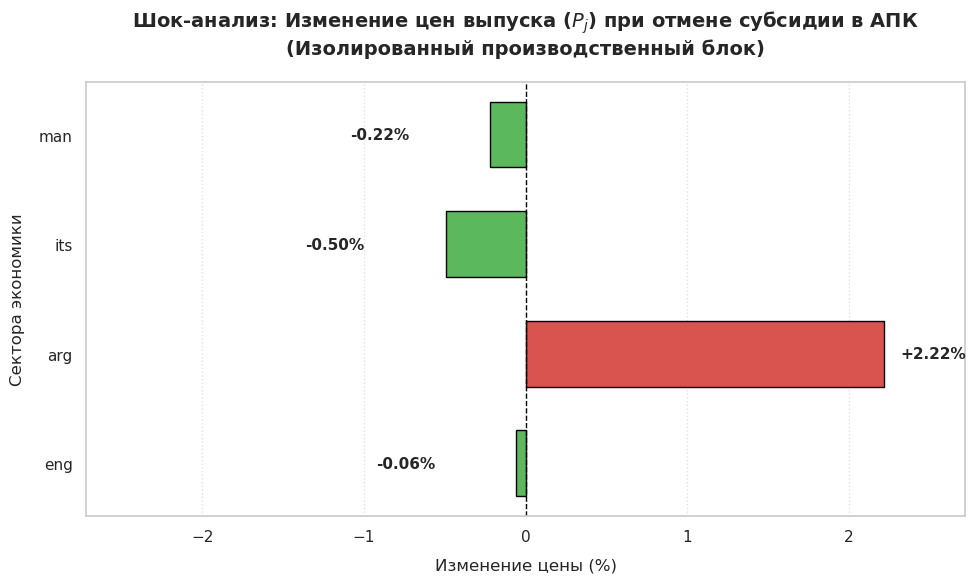

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ИСПРАВЛЕНИЕ: Дропаем сектор CGDS из копии датафрейма исключительно для построения графика
# (чтобы не испортить исходные расчеты в переменной comparison)
plot_data = comparison.drop(index="CGDS", errors="ignore")

# Устанавливаем красивый стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"  # Чтобы корректно отображался русский текст

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(10, 6))

# Положительные изменения красим в красный (удорожание), отрицательные — в зеленый (удешевление)
# ТЕПЕРЬ БЕРЕМ ДАННЫЕ ИЗ plot_data
colors = [
    "#d9534f" if val >= 0 else "#5cb85c" for val in plot_data["Изменение (%)"]
]

# Строим горизонтальный график (используем индекс plot_data)
bars = ax.barh(
    plot_data.index,
    plot_data["Изменение (%)"],
    color=colors,
    edgecolor="black",
    height=0.6,
)

# Добавляем vertical линию на уровне 0% для наглядности
ax.axvline(0, color="black", linestyle="--", linewidth=1)

# Добавляем подписи значений в процентах на сами столбики
for bar in bars:
    width = bar.get_width()
    # Смещение текста в зависимости от знака величины
    x_pos = width + 0.1 if width >= 0 else width - 0.5
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{width:+.2f}%",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=11,
        weight="bold",
    )

# Настройка названий осей и заголовка
ax.set_title(
    "Шок-анализ: Изменение цен выпуска ($P_j$) при отмене субсидии в АПК\n(Изолированный производственный блок)",
    fontsize=14,
    weight="bold",
    pad=20,
)
ax.set_xlabel("Изменение цены (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Сектора экономики", fontsize=12, labelpad=10)

# Настройка лимитов оси X с запасом для текста подписей (берем максимум из plot_data)
max_val = plot_data["Изменение (%)"].abs().max()
ax.set_xlim(-max_val - 0.5, max_val + 0.5)

# Слегка увеличим шрифты осей
ax.tick_params(axis="both", which="major", labelsize=11)

# Тонкая настройка сетки (исправленная ошибка со SyntaxError)
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.grid(axis="y", visible=False)

plt.tight_layout()

# Сохраняем график в папку с результатами
plot_path = f"{output_dir}/subsidy_shock_prices.png"
plt.savefig(plot_path, dpi=300)
print(f"\nГрафик успешно сохранен: '{plot_path}'")

# Показываем график на экране
plt.show()

In [14]:
#блок международной торговли

In [15]:
import os
import numpy as np
import pandas as pd
import re

def load_3d_folder(base_folder, folder_name, col_index_name, file_index_name):
    path = os.path.join(base_folder, folder_name)
    if not os.path.exists(path):
        return None
        
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    all_dfs = []
    
    for file in files:
        reg_name = file.split('_')[1].replace('.csv', '')
        df = read_and_clean_gtap_matrix(os.path.join(path, file))
        
        df_long = df.reset_index().melt(id_vars='index', var_name='col_dim', value_name='value')
        df_long = df_long.rename(columns={'index': 'i', 'col_dim': col_index_name})
        df_long[file_index_name] = reg_name
        
        all_dfs.append(df_long)
        
    final_df = pd.concat(all_dfs, ignore_index=True)
    return final_df.set_index(['i', col_index_name, file_index_name])['value'].sort_index()


In [130]:
base_dir = 'RUSSIA_CSV_DATA_CGE'

#снова сбор данных
VXMD = load_3d_folder(base_dir, 'VXMD', col_index_name='s', file_index_name='r')
VIMS = load_3d_folder(base_dir, 'VIMS', col_index_name='r', file_index_name='s')
VDFA = load_3d_folder(base_dir, 'VDFA', col_index_name='j', file_index_name='s')
VIFA = load_3d_folder(base_dir, 'VIFA', col_index_name='j', file_index_name='s')

sigma_MR_df = read_and_clean_gtap_matrix(os.path.join(base_dir, 'ESUBMR.csv'))
sigma_D_df = read_and_clean_gtap_matrix(os.path.join(base_dir, 'ESUBDR.csv'))
print(sigma_D_df)

      rus   cis   eur  asia   oce   afr   noa   soa   row  Unnamed: 10
eng  6.43  5.35  4.85  3.73  3.62  4.96  4.64  4.54  6.10          0.0
arg  2.24  2.55  2.40  2.51  2.54  2.31  2.16  2.32  2.57          0.0
its  1.90  1.90  1.90  1.90  1.90  1.90  1.90  1.90  1.90          0.0
man  2.93  2.91  3.02  3.12  2.74  2.95  3.05  2.98  2.87          0.0


In [17]:
#калибровка нижнего уровня (alpha_M - доля той или иной страны в импортах) - нужна для формировки PM (сама по себе PM
#не содержит конкретную страну, это взвешанная рыночная цена товара i - из любой страны)

QXS = VXMD.copy()
PMS = (VIMS / QXS).fillna(1.0).replace([np.inf, -np.inf], 1.0)

QIM = QXS.groupby(['i', 's']).sum()
VIM = VIMS.groupby(['i', 's']).sum()
PIM_fact = (VIM / QIM).fillna(1.0)

alpha_M = pd.Series(index=QXS.index, dtype=float)
PIM_model = pd.Series(index=QIM.index, dtype=float)

for (i, s), group in QXS.groupby(['i', 's']):
    qim_val = QIM.loc[(i, s)]
    pim_val = PIM_fact.loc[(i, s)]
    if qim_val == 0:
        continue
        
    sig_M = sigma_MR_df.loc[i, s] if s in sigma_MR_df.columns else sigma_MR_df.iloc[:, 0].loc[i]
    
    ces_sum_lower = 0.0
    for r in group.index.get_level_values('r'):
        qxs_val = QXS.loc[(i, r, s)]
        pms_val = PMS.loc[(i, r, s)]
        
        a_m_val = (qxs_val / qim_val) * ((pms_val / pim_val) ** sig_M)
        alpha_M.loc[(i, r, s)] = a_m_val
        
        ces_sum_lower += a_m_val * (pms_val ** (1 - sig_M))
        
    PIM_model.loc[(i, s)] = ces_sum_lower ** (1 / (1 - sig_M))

discrepancy_low = (PIM_model - PIM_fact).dropna().abs().max()
print(f"сходимость нижнего уровня (разница бухгалтерского и модельного): {discrepancy_low:.2e}")


сходимость нижнего уровня (разница бухгалтерского и модельного): 2.22e-16


In [18]:
#калибровка верхнего уровня (доли отечественных и импортных товаров в промежуточном производстве)

VDFM = load_3d_folder(base_dir, 'VDFM', col_index_name='j', file_index_name='s')
VIFM = load_3d_folder(base_dir, 'VIFM', col_index_name='j', file_index_name='s')

PD = 1.0 

QD = VDFM.copy()  # Поскольку PD = 1.0

QM = pd.Series(index=VIFM.index, dtype=float)
for (i, j, s), vifm_val in VIFM.items():
    pim_price = PIM_fact.get((i, s), 1.0)

    QM.loc[(i, j, s)] = vifm_val / pim_price if pim_price > 0 else 0.0

Q_ARM = QD + QM

alpha_D = pd.Series(index=Q_ARM.index, dtype=float)
alpha_I = pd.Series(index=Q_ARM.index, dtype=float)
PA_agent_model = pd.Series(index=Q_ARM.index, dtype=float)
PA_agent_fact = pd.Series(index=Q_ARM.index, dtype=float)

for (i, j, s), q_arm_val in Q_ARM.items():
    if q_arm_val == 0:
        alpha_D.loc[(i, j, s)] = 0.0
        alpha_I.loc[(i, j, s)] = 0.0
        continue
        
    sig_D = sigma_D_df.loc[i, s] if s in sigma_D_df.columns else sigma_D_df.iloc[:, 0].loc[i]
    
    qd_val = QD.loc[(i, j, s)]
    qm_val = QM.loc[(i, j, s)]
    
    pd_agent = VDFA.loc[(i, j, s)] / qd_val if qd_val > 0 else 1.0
    pm_agent = VIFA.loc[(i, j, s)] / qm_val if qm_val > 0 else PIM_fact.get((i, s), 1.0)
    

    pa_agent = (VDFA.loc[(i, j, s)] + VIFA.loc[(i, j, s)]) / q_arm_val
    PA_agent_fact.loc[(i, j, s)] = pa_agent

    alpha_D.loc[(i, j, s)] = (qd_val / q_arm_val) * ((pd_agent / pa_agent) ** sig_D)
    alpha_I.loc[(i, j, s)] = (qm_val / q_arm_val) * ((pm_agent / pa_agent) ** sig_D)

    a_d = alpha_D.loc[(i, j, s)]
    a_i = alpha_I.loc[(i, j, s)]
    
    ces_sum_upper = (a_d * (pd_agent ** (1 - sig_D))) + (a_i * (pm_agent ** (1 - sig_D)))
    PA_agent_model.loc[(i, j, s)] = ces_sum_upper ** (1 / (1 - sig_D))

PA_agent_model = PA_agent_model.fillna(1.0)
PA_agent_fact = PA_agent_fact.fillna(1.0)

# сходимость цен верхнего уровня для агентов
discrepancy_high = (PA_agent_model - PA_agent_fact).abs().max()
print(f"сходимость верхнего уровня по ценам агентов (max error PA_agent): {discrepancy_high:.2e}")


сходимость верхнего уровня по ценам агентов (max error PA_agent): 4.44e-16


In [19]:
output_dir = 'calibrated_armington_parameters'
os.makedirs(output_dir, exist_ok=True)

alpha_M.dropna().to_csv(f'{output_dir}/alpha_M_trade.csv', sep=';', header=['value'])
alpha_D.dropna().to_csv(f'{output_dir}/alpha_D_domestic.csv', sep=';', header=['value'])
alpha_I.dropna().to_csv(f'{output_dir}/alpha_I_import.csv', sep=';', header=['value'])

In [20]:

VXWD = load_3d_folder(base_dir, 'VXWD', col_index_name='s', file_index_name='r')
TFRV = load_3d_folder(base_dir, 'TFRV', col_index_name='r', file_index_name='s')

tx_3d = (VXWD - VXMD) / VXMD
tx_3d = tx_3d.fillna(0.0).replace([np.inf, -np.inf], 0.0)

tm_3d = TFRV / VIMS
tm_3d = tm_3d.fillna(0.0).replace([np.inf, -np.inf], 0.0)

target_country = 'rus'

# это ИЗ других регионов В Россию (томоженные пошлины РФ (ПР. УТИЛЬСБОР))
# Индекс tm_3d: ['i', 'r', 's'] -> достаем срез по уровню 's'
tm_rus = tm_3d.xs(target_country, level='s')

# это ИЗ России В другие регионы
# Индекс tx_3d: ['i', 's', 'r'] -> достаем срез по уровню 'r'
tx_rus = tx_3d.xs(target_country, level='r')

output_dir = 'calibrated_armington_parameters'
os.makedirs(output_dir, exist_ok=True)

tm_rus = tm_rus.drop(labels='Unnamed: 10', level='r', errors='ignore')
tx_rus = tx_rus.drop(labels='Unnamed: 10', level='s', errors='ignore')

tm_rus.to_csv(f'{output_dir}/tm_import_tariffs.csv', sep=';', header=['value'])
tx_rus.to_csv(f'{output_dir}/tx_export_duties.csv', sep=';', header=['value'])


In [21]:
print('tm\n', tm_rus)
print('\ntx\n', tx_rus)

tm
 i    r   
arg  afr     0.041262
     asia    0.039640
     cis     0.000000
     eur     0.062018
     noa     0.019485
     oce     0.019048
     row     0.080691
     rus     0.000000
     soa     0.022458
eng  afr     0.019770
     asia    0.019478
     cis     0.000000
     eur     0.012063
     noa     0.001307
     oce     0.035934
     row     0.001976
     rus     0.000000
     soa     0.003237
its  afr     0.000000
     asia    0.000000
     cis     0.000000
     eur     0.000000
     noa     0.000000
     oce     0.000000
     row     0.000000
     rus     0.000000
     soa     0.000000
man  afr     0.047464
     asia    0.075343
     cis     0.000008
     eur     0.074418
     noa     0.084580
     oce     0.071727
     row     0.049465
     rus     0.000000
     soa     0.144502
Name: value, dtype: float64

tx
 i    s   
arg  afr     0.000000
     asia    0.000000
     cis     0.001012
     eur    -0.000656
     noa     0.001927
     oce     0.000000
     row    -0.0017

In [24]:
#получилось норм

In [34]:
if 'sigma_D' not in locals() and 'sigma_D' not in globals():
    try:

        esubd_raw = read_and_clean_gtap_matrix('RUSSIA_CSV_DATA_CGE/ESUBD.csv')
        
        if isinstance(esubd_raw, pd.Series):
            sigma_D = esubd_raw
        elif isinstance(esubd_raw, pd.DataFrame):
            sigma_D = esubd_raw.iloc[:, 0] if esubd_raw.shape[1] == 1 else esubd_raw.iloc[0, :]
        
        print("Переменная sigma_D успешно загружена из ESUBD.csv")
    except Exception as e:
        print(f"Не удалось загрузить ESUBD.csv ({e}). Используем дефолтное значение 2.0 для всех секторов.")
        sigma_D = pd.Series(2.0, index=sectors)

sigma_D = sigma_D.apply(lambda x: 2.0 if x == 1.0 else x)

Не удалось загрузить ESUBD.csv ([Errno 2] No such file or directory: 'RUSSIA_CSV_DATA_CGE/ESUBD.csv'). Используем дефолтное значение 2.0 для всех секторов.


In [36]:
import numpy as np
import pandas as pd

print("эксперимент изолированно в блоке торговли")

def to_matrix(data):
    if isinstance(data, pd.Series):
        levels = data.index.names
        i_lvl = 'i' if 'i' in levels else 0
        j_lvl = 'j' if 'j' in levels else 1
        return data.groupby(level=[i_lvl, j_lvl]).sum().unstack(level=j_lvl)
    return pd.DataFrame(data)

VDFM_mat = to_matrix(VDFM)
VIFM_mat = to_matrix(VIFM)

if isinstance(EVFA, pd.DataFrame):
    EVFA_j = EVFA.sum(axis=0)
else:
    EVFA_j = EVFA.groupby(level='j' if 'j' in EVFA.index.names else 1).sum()

VOM_j = EVFA_j + VDFM_mat.sum(axis=0) + VIFM_mat.sum(axis=0)

theta_VA = (EVFA_j / VOM_j).fillna(0.0)
theta_D_ij = VDFM_mat.div(VOM_j, axis=1).fillna(0.0)
theta_I_ij = VIFM_mat.div(VOM_j, axis=1).fillna(0.0)

#ШОК
tf_scenario = tf.copy()

tf_scenario.loc["UnSkLab", "arg"] = 0.52
tf_scenario.loc["Capital", "eng"] = 0.52


p_VA = pd.Series(1.0, index=sectors)

print("\n--- Проверка: считывание шока ---")
for j in sectors:
    if hasattr(tf, 'columns') and j in tf.columns and j in delta_fixed.columns:
        tax_ratio = (1 + tf_scenario[j]) / (1 + tf[j])
        p_VA[j] = np.prod(tax_ratio ** delta_fixed[j])
        
    if p_VA[j] != 1.0:
        print(f"Отрасль '{j}': индекс базовой цены факторов сдвинулся -> {p_VA[j]:.6f}")

if (p_VA == 1.0).all():
    print("ВНИМАНИЕ: Шок не считался! Все индексы p_VA = 1.0")

p_prod = pd.Series(1.0, index=sectors)
iteration = 0
max_iterations = 100
tolerance = 1e-7

while iteration < max_iterations:
    iteration += 1
    p_prod_old = p_prod.copy()
    
    pD_market = p_prod_old.copy()       
    pM_market = pd.Series(1.0, index=sectors) 
    
    p_prod_new = pd.Series(0.0, index=sectors)
    
    for j in sectors:
        cost_j = theta_VA[j] * p_VA[j]
        
        for i in sectors:
            sig_D = sigma_D.get(i, 2.0) if hasattr(sigma_D, 'get') else (sigma_D[i] if i in sigma_D.index else 2.0)
            
            total_fm = VDFM_mat.loc[i, j] + VIFM_mat.loc[i, j] if i in VDFM_mat.index and j in VDFM_mat.columns else 0.0
            
            if total_fm > 0:
                sh_D_local = VDFM_mat.loc[i, j] / total_fm
                sh_I_local = VIFM_mat.loc[i, j] / total_fm
                pA_change = (sh_D_local * (pD_market[i] ** (1 - sig_D)) + sh_I_local * (pM_market[i] ** (1 - sig_D))) ** (1 / (1 - sig_D))
            else:
                pA_change = 1.0
            
            if i in theta_D_ij.index:
                cost_j += theta_D_ij.loc[i, j] * pA_change
            if i in theta_I_ij.index:
                cost_j += theta_I_ij.loc[i, j] * pA_change
                
        p_prod_new[j] = cost_j
        
    p_prod = p_prod_new
    
    if (p_prod - p_prod_old).abs().max() < tolerance:
        break

# --- 6. ВЫВОД РЕЗУЛЬТАТОВ ---
comparison = pd.DataFrame({
    "Базовый индекс": 1.0,
    "Новый индекс": p_prod,
    "Изменение цен (%)": (p_prod - 1.0) * 100
}, index=sectors)

print("\n=== СРАВНЕНИЕ ИНДЕКСОВ ИЗМЕНЕНИЯ ЦЕН В РЕЗУЛЬТАТЕ ШОКА ===")
print(comparison.round(6))

эксперимент изолированно в блоке торговли

--- Проверка: считывание шока ---
Отрасль 'eng': индекс базовой цены факторов сдвинулся -> 1.232083
Отрасль 'arg': индекс базовой цены факторов сдвинулся -> 1.089951

=== СРАВНЕНИЕ ИНДЕКСОВ ИЗМЕНЕНИЯ ЦЕН В РЕЗУЛЬТАТЕ ШОКА ===
      Базовый индекс  Новый индекс  Изменение цен (%)
eng              1.0      1.027732           2.773233
arg              1.0      1.008878           0.887824
its              1.0      1.005164           0.516371
man              1.0      1.006143           0.614264
CGDS             1.0      1.005169           0.516946


In [118]:
import numpy as np
import pandas as pd

print("эксперимент на всей модели")

def to_matrix(data):
    if isinstance(data, pd.Series):
        levels = data.index.names
        i_lvl = 'i' if 'i' in levels else 0
        j_lvl = 'j' if 'j' in levels else 1
        return data.groupby(level=[i_lvl, j_lvl]).sum().unstack(level=j_lvl)
    return pd.DataFrame(data)

VDFM_mat = to_matrix(VDFM)
VIFM_mat = to_matrix(VIFM)

if isinstance(EVFA, pd.DataFrame):
    EVFA_j = EVFA.sum(axis=0)
else:
    EVFA_j = EVFA.groupby(level='j' if 'j' in EVFA.index.names else 1).sum()

VOM_j = EVFA_j + VDFM_mat.sum(axis=0) + VIFM_mat.sum(axis=0)

theta_VA = (EVFA_j / VOM_j).fillna(0.0)
theta_D_ij = VDFM_mat.div(VOM_j, axis=1).fillna(0.0)
theta_I_ij = VIFM_mat.div(VOM_j, axis=1).fillna(0.0)

### ТУТ ШОКИ ##########################################################################

#ШОКИ БЛОКА ПРОИЗВОДСТВА
tf_scenario = tf.copy()
tf_scenario.loc["UnSkLab", "arg"] = -0.52
#tf_scenario.loc["Capital", "eng"] = 0.52
#tf_scenario.loc[:, :] = 0
# tf_scenario.loc[:, :] = tf.loc[:, :] 

if 'tm' in locals() or 'tm' in globals():
    tm_base = tm.copy()
else:
    tm_base = pd.Series(0.0, index=sectors)

tm_scenario = tm_base.copy()

#ШОКИ БЛОКА МЕЖДУНАРОДНОЙ ТОРГОВОЛИ
#шок импортных пошлин
if "man" in tm_scenario.index:
    tm_scenario["man"] -= 0.20
if "eng" in tm_scenario.index:
    tm_scenario["eng"] += 0.20

#######################################################################################

p_VA = pd.Series(1.0, index=sectors)
for j in sectors:
    if hasattr(tf, 'columns') and j in tf.columns and j in delta_fixed.columns:
        tax_ratio = (1 + tf_scenario[j]) / (1 + tf[j])
        p_VA[j] = np.prod(tax_ratio ** delta_fixed[j])



p_prod = pd.Series(1.0, index=sectors)
iteration = 0
max_iterations = 100
tolerance = 1e-7


while iteration < max_iterations:
    iteration += 1
    p_prod_old = p_prod.copy()
    
    pD_market = p_prod_old.copy()       
    
    pM_market = pd.Series(1.0, index=sectors)
    for i in sectors:
        if i in tm_scenario.index and i in tm_base.index:
            pM_market[i] = (1 + tm_scenario[i]) / (1 + tm_base[i]) #считаем
    
    p_prod_new = pd.Series(0.0, index=sectors)
    
    for j in sectors:
        cost_j = theta_VA[j] * p_VA[j] #затраты на факторы
        
        for i in sectors:
            sig_D = sigma_D.get(i, 2.0) if hasattr(sigma_D, 'get') else (sigma_D[i] if i in sigma_D.index else 2.0)
            
            total_fm = VDFM_mat.loc[i, j] + VIFM_mat.loc[i, j] if i in VDFM_mat.index and j in VDFM_mat.columns else 0.0
            
            if total_fm > 0:
                sh_D_local = VDFM_mat.loc[i, j] / total_fm
                sh_I_local = VIFM_mat.loc[i, j] / total_fm
                
                pA_change = (sh_D_local * (pD_market[i] ** (1 - sig_D)) + sh_I_local * (pM_market[i] ** (1 - sig_D))) ** (1 / (1 - sig_D)) #наша CES функция
                
                theta_A_local = 0.0
                if i in theta_D_ij.index:
                    theta_A_local += theta_D_ij.loc[i, j]
                if i in theta_I_ij.index:
                    theta_A_local += theta_I_ij.loc[i, j]
                
                cost_j += theta_A_local * pA_change
                
                
        p_prod_new[j] = cost_j
        
    p_prod = p_prod_new
    
    if (p_prod - p_prod_old).abs().max() < tolerance:
        break

comparison = pd.DataFrame({
    "Базовый индекс": 1.0,
    "Новый индекс": p_prod,
    "Изменение цен (%)": (p_prod - 1.0) * 100
}, index=sectors)

print(f"\nРавновесие достигнуто на итерации: {iteration}")
print("\nшок импортных пошлин tm и налогов на факторы труда tf")
print(comparison.round(6))

эксперимент на всей модели

Равновесие достигнуто на итерации: 59

шок импортных пошлин tm и налогов на факторы труда tf
      Базовый индекс  Новый индекс  Изменение цен (%)
eng              1.0      0.935262          -6.473776
arg              1.0      0.889542         -11.045796
its              1.0      0.906263          -9.373738
man              1.0      0.901534          -9.846622
CGDS             1.0      0.888047         -11.195257


In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_cge_results(p_prod_series, title_text="Изменение цен по отраслям"):
    """Функция автоматического построения графика для любых результатов CGE-модели.

    p_prod_series: pd.Series, где index — это sectors, а значения — новые индексы
    цен (p_prod)
    """
    # 1. Формируем DataFrame и считаем изменение в %
    df = pd.DataFrame(
        {"New_Index": p_prod_series, "Change_Pct": (p_prod_series - 1.0) * 100}
    )

    # Словарь человеческих названий (если сектора изменятся, код не упадет)
    name_mapping = {
        "eng": "Энергетика (eng)",
        "man": "Промышленность (man)",
        "CGDS": "Сбережерния и инвестиции (CGDS)",
        "arg": "Сельское хозяйство (arg)",
        "its": "IT и Услуги (its)",
    }
    df["Sector_Name"] = df.index.map(lambda x: name_mapping.get(x, f"Сектор {x}"))

    # Сортируем по абсолютному значению изменения, чтобы самые важные были вверху
    df["Abs_Change"] = df["Change_Pct"].abs()
    df = df.sort_values(by="Change_Pct", ascending=True)

    # 2. Автоматическое определение цвета (выделяем максимальный абсолютный шок)
    max_shock_idx = df["Abs_Change"].idxmax()

    colors = []
    for idx in df.index:
        if idx == max_shock_idx:
            # Если цена росла — красный, если падала — глубокий синий (дефляция)
            colors.append("#ff165d" if df.loc[idx, "Change_Pct"] >= 0 else "#005f73")
        else:
            # Для остальных отраслей — нейтральный серый/голубой
            colors.append("#bde0fe" if df.loc[idx, "Change_Pct"] >= 0 else "#e0e0e0")

    # 3. Настройка поля графика
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10, len(df) * 1.1), dpi=150)  # Высота подстраивается под число секторов

    # 4. Отрисовка баров
    bars = ax.barh(
        df["Sector_Name"],
        df["Change_Pct"],
        color=colors,
        edgecolor="#333333",
        height=0.6,
    )

    # 5. Автоматические лимиты осей с запасом под текст
    max_val = df["Change_Pct"].max()
    min_val = df["Change_Pct"].min()

    # Задаем отступы для текстовых меток
    if max_val > 0:
        ax.set_xlim(right=max_val * 1.25 if max_val > 0 else 0.5)
    if min_val < 0:
        ax.set_xlim(left=min_val * 1.25)

    # Отрисовка нулевой линии баланса
    ax.axvline(0, color="#333333", linewidth=1.2, linestyle="--", alpha=0.7)

    # 6. Динамическое добавление подписей к столбцам
    for bar in bars:
        width = bar.get_width()
        # Определяем положение текста в зависимости от знака изменения
        if width >= 0:
            text_x = width + (max_val * 0.02 if max_val > 0 else 0.02)
            ha_zone = "left"
            sign = "+"
        else:
            text_x = width - (abs(min_val) * 0.02 if min_val < 0 else 0.02)
            ha_zone = "right"
            sign = ""

        ax.text(
            text_x,
            bar.get_y() + bar.get_height() / 2,
            f"{sign}{width:.3f}%",
            va="center",
            ha=ha_zone,
            fontsize=10,
            fontweight="bold",
            color="#2b2b2b",
        )

    # 7. Оформление осей
    ax.set_title(
        title_text,
        fontsize=12,
        fontweight="bold",
        pad=20,
        loc="left",
        color="#1a1a1a",
    )
    ax.set_xlabel("Изменение цен производителей (%)", fontsize=11, labelpad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    plt.tight_layout()

    # Сохраняем результат
    plt.savefig("cge_simulation_output.png", bbox_inches="tight", dpi=300)
    plt.show()


# ==============================================================================
# ПРИМЕР ВЫЗОВА: Просто передай p_prod после итерационного цикла
# ==============================================================================
# Сейчас в твоем коде переменная `p_prod` хранит финальный pd.Series.
# Достаточно написать в самом конце скрипта:
#
# plot_cge_results(p_prod, title_text="Моделирование шока импортных пошлин tm на сектор 'eng'")

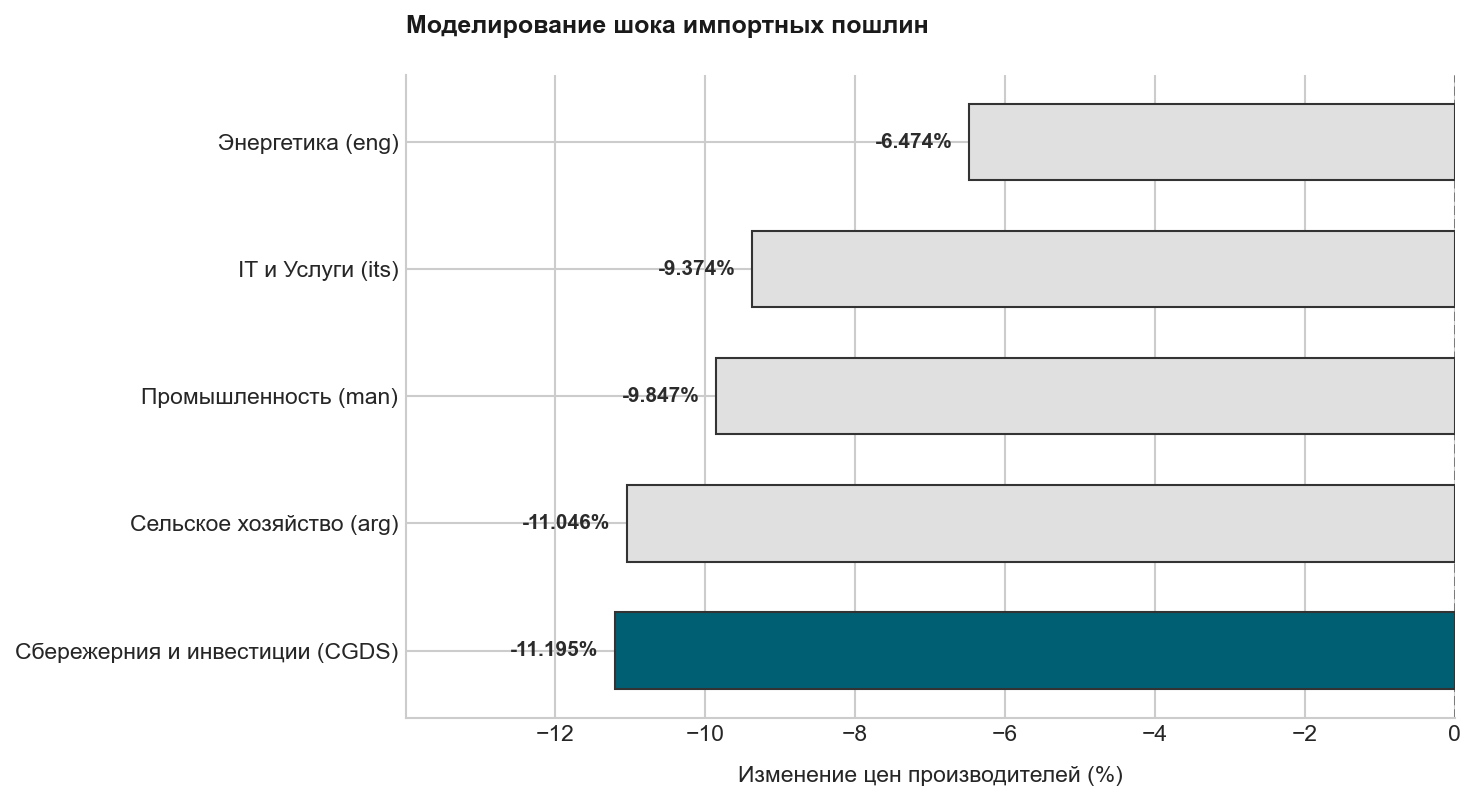

In [122]:
plot_cge_results(p_prod, title_text="Моделирование шока импортных пошлин")

In [136]:
import numpy as np
import pandas as pd

print("Эксперимент 3: Шок мировых экспортных цен на IT-услуги")

def to_matrix(data):
    if isinstance(data, pd.Series):
        levels = data.index.names
        i_lvl = 'i' if 'i' in levels else 0
        j_lvl = 'j' if 'j' in levels else 1
        return data.groupby(level=[i_lvl, j_lvl]).sum().unstack(level=j_lvl)
    return pd.DataFrame(data)

VDFM_mat = to_matrix(VDFM)
VIFM_mat = to_matrix(VIFM)

if isinstance(EVFA, pd.DataFrame):
    EVFA_j = EVFA.sum(axis=0)
else:
    EVFA_j = EVFA.groupby(level='j' if 'j' in EVFA.index.names else 1).sum()

VOM_j = EVFA_j + VDFM_mat.sum(axis=0) + VIFM_mat.sum(axis=0)

theta_VA = (EVFA_j / VOM_j).fillna(0.0)
theta_D_ij = VDFM_mat.div(VOM_j, axis=1).fillna(0.0)
theta_I_ij = VIFM_mat.div(VOM_j, axis=1).fillna(0.0)

### ТУТ ШОКИ ##########################################################################

#ШОКИ БЛОКА ПРОИЗВОДСТВА (Отключены для чистоты эксперимента)
tf_scenario = tf.copy()
# tf_scenario.loc["UnSkLab", "arg"] = -0.52
# tf_scenario.loc["Capital", "eng"] = 0.52

#ШОКИ ПОШЛИН (Оставляем базовыми, без изменений)
if 'tm' in locals() or 'tm' in globals():
    tm_base = tm.copy()
else:
    tm_base = pd.Series(0.0, index=sectors)
tm_scenario = tm_base.copy()

#ШОКИ БЛОКА МЕЖДУНАРОДНОЙ ТОРГОВОЛИ
#шок импортных пошлин
if "man" in tm_scenario.index:
    tm_scenario["man"] -= 0
if "eng" in tm_scenario.index:
    tm_scenario["eng"] += 0

#ШОКИ МИРОВЫХ ЦЕН (P_world)
# Изначально все мировые цены равны 1.0
pW_scenario = pd.Series(1.0, index=sectors)

# ВВОДИМ ШОК: Зарубежные IT-услуги подорожали на 20%
if "its" in pW_scenario.index:
    pW_scenario["its"] = 1.20
    pW_scenario["man"] = 0.80 

#######################################################################################

p_VA = pd.Series(1.0, index=sectors)
for j in sectors:
    if hasattr(tf, 'columns') and j in tf.columns and j in delta_fixed.columns:
        tax_ratio = (1 + tf_scenario[j]) / (1 + tf[j])
        p_VA[j] = np.prod(tax_ratio ** delta_fixed[j])

p_prod = pd.Series(1.0, index=sectors)
iteration = 0
max_iterations = 100
tolerance = 1e-7

while iteration < max_iterations:
    iteration += 1
    p_prod_old = p_prod.copy()
    
    pD_market = p_prod_old.copy()        
    
    # --- ОБНОВЛЕННЫЙ РАСЧЕТ ИМПОРТНЫХ ЦЕН ---
    pM_market = pd.Series(1.0, index=sectors)
    for i in sectors:
        # Считаем таможенный коэффициент
        tariff_ratio = (1 + tm_scenario[i]) / (1 + tm_base[i]) if (i in tm_scenario.index and i in tm_base.index) else 1.0
        # Цена импорта = Мировая цена * Таможенный коэффициент
        pM_market[i] = pW_scenario[i] * tariff_ratio 
    
    p_prod_new = pd.Series(0.0, index=sectors)
    
    for j in sectors:
        cost_j = theta_VA[j] * p_VA[j] 
        
        for i in sectors:
            sig_D = sigma_D.get(i, 2.0) if hasattr(sigma_D, 'get') else (sigma_D[i] if i in sigma_D.index else 2.0)
            
            total_fm = VDFM_mat.loc[i, j] + VIFM_mat.loc[i, j] if i in VDFM_mat.index and j in VDFM_mat.columns else 0.0
            
            if total_fm > 0:
                sh_D_local = VDFM_mat.loc[i, j] / total_fm
                sh_I_local = VIFM_mat.loc[i, j] / total_fm
                
                # Функция Армингтона использует обновленный pM_market, в котором уже сидит pW_scenario
                pA_change = (sh_D_local * (pD_market[i] ** (1 - sig_D)) + sh_I_local * (pM_market[i] ** (1 - sig_D))) ** (1 / (1 - sig_D)) 
                
                theta_A_local = 0.0
                if i in theta_D_ij.index:
                    theta_A_local += theta_D_ij.loc[i, j]
                if i in theta_I_ij.index:
                    theta_A_local += theta_I_ij.loc[i, j]
                
                cost_j += theta_A_local * pA_change
                
        p_prod_new[j] = cost_j
        
    p_prod = p_prod_new
    
    if (p_prod - p_prod_old).abs().max() < tolerance:
        break

comparison = pd.DataFrame({
    "Базовый индекс": 1.0,
    "Новый индекс": p_prod,
    "Изменение цен (%)": (p_prod - 1.0) * 100
}, index=sectors)

print(f"\nРавновесие достигнуто на итерации: {iteration}")
print("\nШок мировых цен: удорожание импорта IT-услуг (its) на +20% и уменьшение на Производство (man) на 20%")
print(comparison.round(6))

# plot_cge_results(p_prod, title_text="Влияние мирового роста цен на IT-услуги (+20%)")

Эксперимент 3: Шок мировых экспортных цен на IT-услуги

Равновесие достигнуто на итерации: 60

Шок мировых цен: удорожание импорта IT-услуг (its) на +20% и уменьшение на Производство (man) на 20%
      Базовый индекс  Новый индекс  Изменение цен (%)
eng              1.0      0.926392          -7.360779
arg              1.0      0.907690          -9.231022
its              1.0      0.924631          -7.536902
man              1.0      0.900811          -9.918923
CGDS             1.0      0.891475         -10.852461


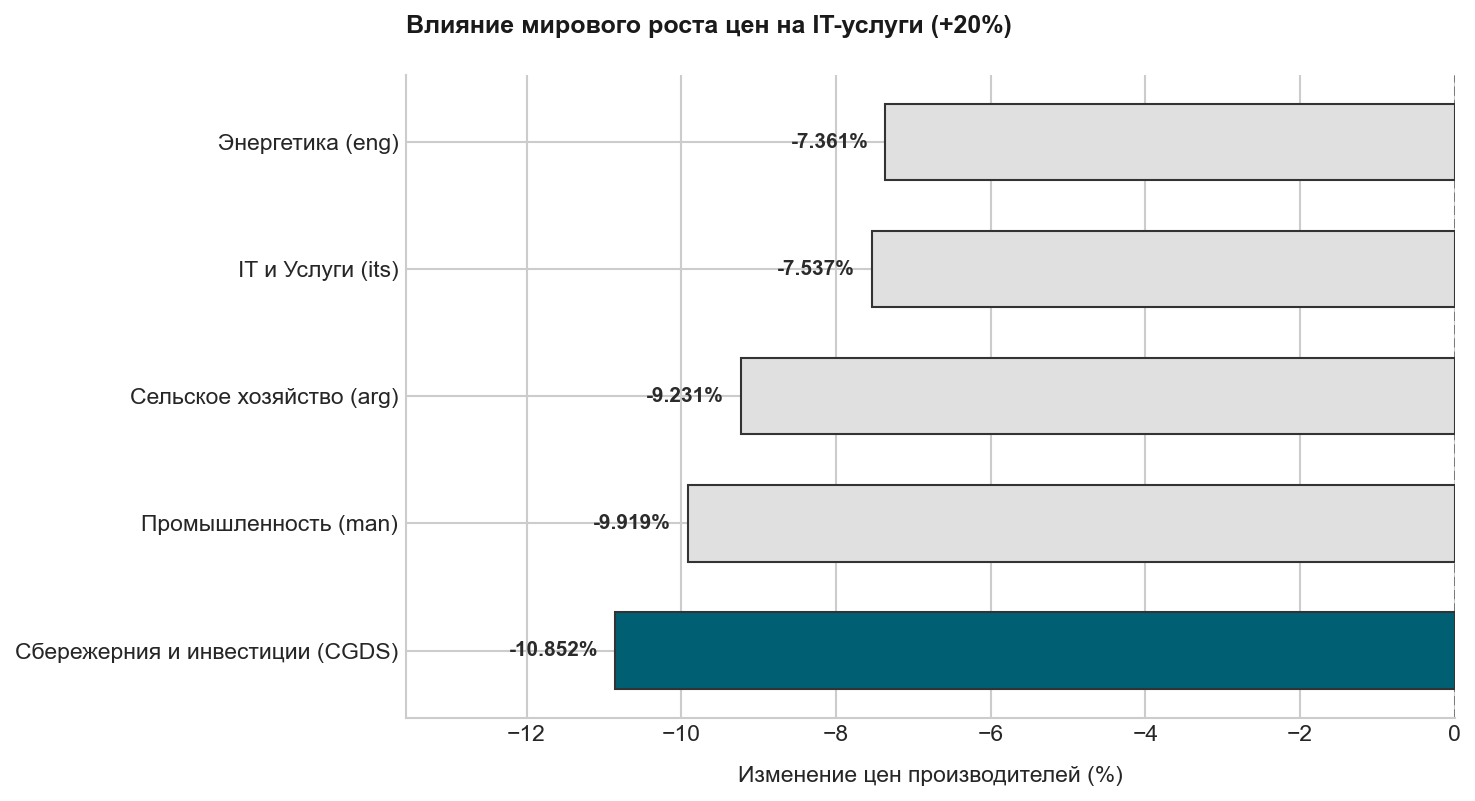

In [134]:
plot_cge_results(p_prod, title_text="Влияние мирового роста цен на IT-услуги (+20%)")